# Week 1: IoT Telemetry Ingestion and Signal Processing

## Introduction

The objective of Week 1 is to prepare the AI4I Predictive Maintenance dataset for machine learning by performing data ingestion, preprocessing, exploratory data analysis (EDA), and signal processing. The dataset contains machine sensor measurements such as air temperature, process temperature, rotational speed, torque, and tool wear, which are used to predict machine failures.

During this phase, the dataset is cleaned, analyzed, and transformed into a structured format suitable for predictive modeling. Rolling statistical features such as rolling mean, rolling standard deviation, and rolling variance are generated to capture short-term trends in sensor readings. Additional engineered features are also created to improve the quality of the data for subsequent machine learning tasks.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\tange\Downloads\ai4i2020.csv")

In [4]:
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df.drop_duplicates()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [11]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [19]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [21]:
df.drop(columns=['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace=True)

In [22]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0
9996,0,298.9,308.4,1632,31.8,17,0
9997,2,299.0,308.6,1645,33.4,22,0
9998,0,299.0,308.7,1408,48.5,25,0


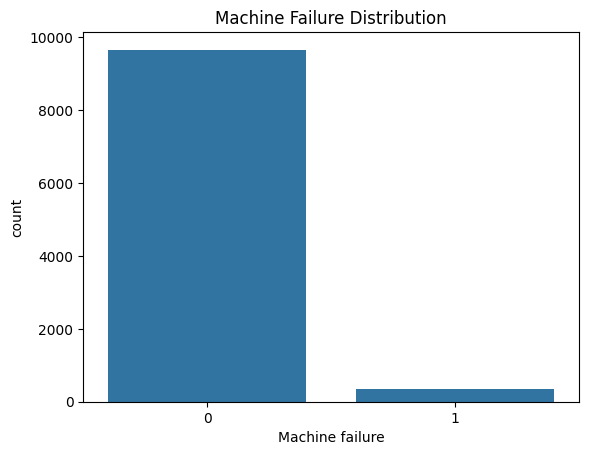

In [24]:
# Class distribution
import seaborn as sns
sns.countplot(x='Machine failure', data=df)
plt.title("Machine Failure Distribution")
plt.show()

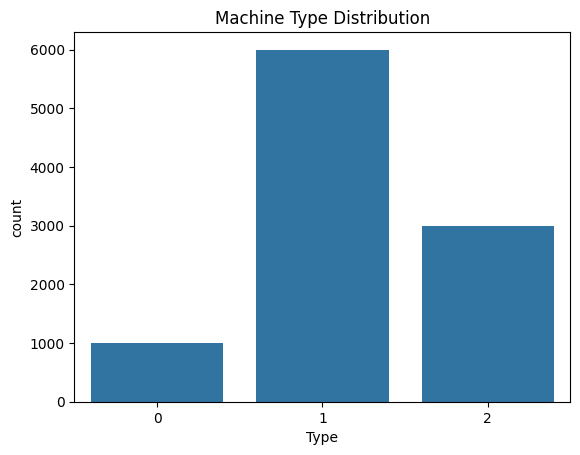

In [25]:
# Machine type distribution
sns.countplot(x='Type', data=df)
plt.title("Machine Type Distribution")
plt.show()

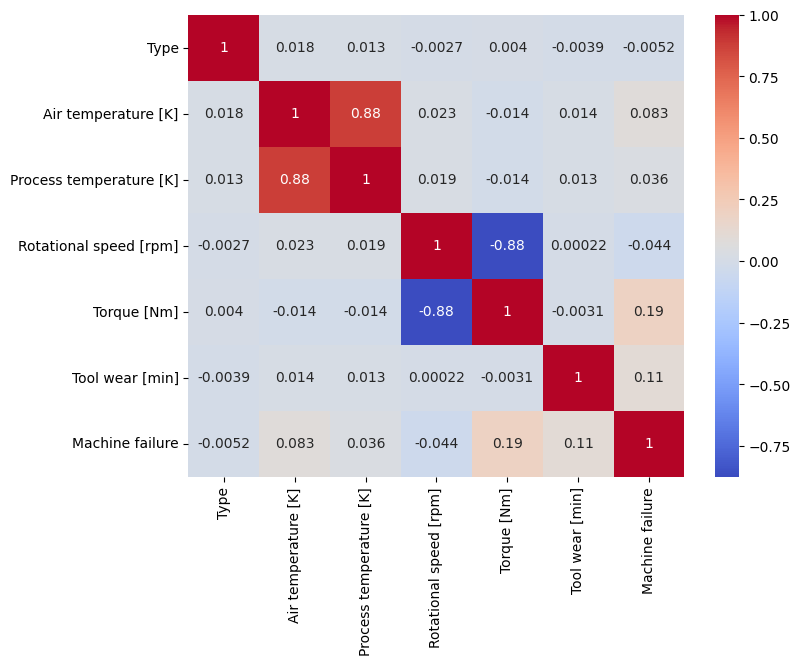

In [26]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

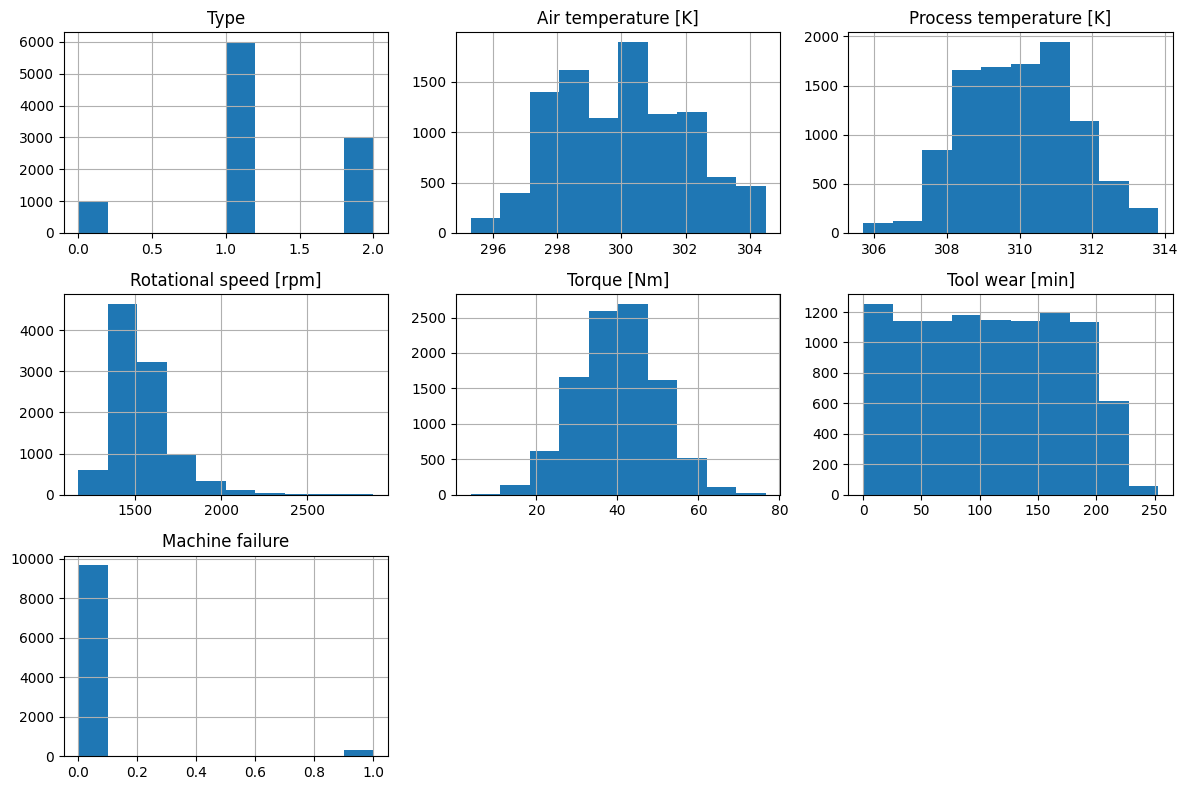

In [27]:
# Histograms
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [29]:
# Rolling Mean, Standard Deviation, and Variance
window_size = 5

# Air Temperature
df['AirTemp_RollingMean'] = df['Air temperature [K]'].rolling(window=window_size).mean()
df['AirTemp_RollingStd'] = df['Air temperature [K]'].rolling(window=window_size).std()
df['AirTemp_RollingVar'] = df['Air temperature [K]'].rolling(window=window_size).var()

# Process Temperature
df['ProcessTemp_RollingMean'] = df['Process temperature [K]'].rolling(window=window_size).mean()
df['ProcessTemp_RollingStd'] = df['Process temperature [K]'].rolling(window=window_size).std()
df['ProcessTemp_RollingVar'] = df['Process temperature [K]'].rolling(window=window_size).var()

# Rotational Speed
df['RPM_RollingMean'] = df['Rotational speed [rpm]'].rolling(window=window_size).mean()
df['RPM_RollingStd'] = df['Rotational speed [rpm]'].rolling(window=window_size).std()
df['RPM_RollingVar'] = df['Rotational speed [rpm]'].rolling(window=window_size).var()

# Torque
df['Torque_RollingMean'] = df['Torque [Nm]'].rolling(window=window_size).mean()
df['Torque_RollingStd'] = df['Torque [Nm]'].rolling(window=window_size).std()
df['Torque_RollingVar'] = df['Torque [Nm]'].rolling(window=window_size).var()

# Tool Wear
df['ToolWear_RollingMean'] = df['Tool wear [min]'].rolling(window=window_size).mean()
df['ToolWear_RollingStd'] = df['Tool wear [min]'].rolling(window=window_size).std()
df['ToolWear_RollingVar'] = df['Tool wear [min]'].rolling(window=window_size).var()

In [30]:
df = df.dropna().reset_index(drop=True)

In [31]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,AirTemp_RollingVar,ProcessTemp_RollingMean,ProcessTemp_RollingStd,ProcessTemp_RollingVar,RPM_RollingMean,RPM_RollingStd,RPM_RollingVar,ToolWear_RollingMean,ToolWear_RollingStd,ToolWear_RollingVar
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,0.003,308.62,0.083666,0.007,1459.6,62.970628,3965.3,4.8,3.492850,12.2
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,0.003,308.62,0.083666,0.007,1434.4,37.179295,1382.3,7.0,3.162278,10.0
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,0.003,308.60,0.070711,0.005,1464.4,62.468392,3902.3,9.2,3.492850,12.2
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,0.003,308.62,0.044721,0.002,1470.2,67.510740,4557.7,11.4,3.646917,13.3
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,0.008,308.64,0.054772,0.003,1517.0,105.624334,11156.5,13.6,3.646917,13.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,0.002,308.38,0.044721,0.002,1590.0,162.217447,26314.5,9.8,3.492850,12.2
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,0.002,308.38,0.044721,0.002,1551.0,103.980767,10812.0,12.2,3.492850,12.2
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,0.008,308.42,0.109545,0.012,1583.2,102.969413,10602.7,15.0,4.690416,22.0
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,0.010,308.48,0.164317,0.027,1584.6,99.873921,9974.8,18.0,5.431390,29.5


In [32]:
# Temperature Difference
df['Temp_Difference'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Power Index
df['Power_Index'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# Wear-Torque Interaction
df['Wear_Torque'] = df['Tool wear [min]'] * df['Torque [Nm]']

# Temperature Ratio
df['Temp_Ratio'] = df['Process temperature [K]'] / df['Air temperature [K]']

# RPM per Torque
df['RPM_per_Torque'] = df['Rotational speed [rpm]'] / (df['Torque [Nm]'] + 1)

In [33]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,RPM_RollingStd,RPM_RollingVar,ToolWear_RollingMean,ToolWear_RollingStd,ToolWear_RollingVar,Temp_Difference,Power_Index,Wear_Torque,Temp_Ratio,RPM_per_Torque
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,62.970628,3965.3,4.8,3.492850,12.2,10.5,56320.0,360.0,1.035211,34.341463
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,37.179295,1382.3,7.0,3.162278,10.0,10.5,59707.5,460.9,1.035223,33.216783
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,62.468392,3902.3,9.2,3.492850,12.2,10.5,66059.2,593.6,1.035223,35.898618
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,67.510740,4557.7,11.4,3.646917,13.3,10.5,61385.4,643.2,1.035223,37.063107
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,105.624334,11156.5,13.6,3.646917,13.3,10.4,47676.2,514.8,1.034864,56.317568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,162.217447,26314.5,9.8,3.492850,12.2,9.6,47318.0,413.0,1.032129,52.590164
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,103.980767,10812.0,12.2,3.492850,12.2,9.5,51897.6,540.6,1.031783,49.756098
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,102.969413,10602.7,15.0,4.690416,22.0,9.6,54943.0,734.8,1.032107,47.819767
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,99.873921,9974.8,18.0,5.431390,29.5,9.7,68288.0,1212.5,1.032441,28.444444


In [34]:
df.to_csv("week1_processed_data.csv", index=False)

# Week 1 Summary

In Week 1, the AI4I Predictive Maintenance dataset was successfully loaded, cleaned, and explored. Data preprocessing included handling categorical variables, checking data quality, and preparing the dataset for analysis. Exploratory Data Analysis (EDA) was performed to understand the distribution of sensor features and machine failures.

Signal processing techniques were applied by computing rolling statistical features, and several engineered features were created to enhance the predictive capability of the dataset. The processed dataset is now ready for Week 2, where contextual environmental information will be integrated through contextual data fusion and advanced feature engineering.